In [1]:
import polars as pl 
from dbconfig import engine 
print('environment ready!')

environment ready!


In [2]:
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_float_precision(2)

polars.config.Config

In [7]:
pl.read_database(
        query ="""
        select table_name
        from information_schema.tables
        where table_schema in ('benchmark', 'analysis')
        order by table_name;
        """, connection = engine
        )

table_name
str
"""inflation"""
"""nifty_50_fixed"""
"""nifty_50_full"""
"""nifty_50_half"""
"""nifty_historical_fixed"""
"""nifty_historical_fixed_summary"""
"""nifty_historical_full"""
"""nifty_historical_full_summary"""
"""nifty_historical_half"""


In [46]:
dd_fixed = pl.read_database(
        query = """
        select *,
        max(nominal_corpus) over(
            order by date
            ) as running_peak
        from analysis.nifty_historical_fixed;
        """, connection = engine
        )

In [10]:
dd_fixed.head()

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1995-12-01,908.53,5000.00,5.50,5.50,5000.00,5000.00,0.00,1.00,5000.00,5000.00,0.00,100.00,5000.00
1996-01-01,848.42,5000.00,5.89,11.40,10000.00,9536.38,-330.81,1.10,9669.19,8772.63,-763.75,91.99,9669.19
1996-02-01,992.51,5000.00,5.04,16.43,15000.00,14072.76,1311.34,1.10,16311.34,14798.89,726.13,105.16,16311.34
1996-03-01,985.30,5000.00,5.07,21.51,20000.00,18609.15,1192.85,1.10,21192.85,19227.77,618.63,103.32,21192.85
1996-04-01,1114.36,5000.00,4.49,26.00,25000.00,23145.53,3968.81,1.10,28968.81,26282.71,3137.18,113.55,28968.81


In [47]:
dd_half = pl.read_database(
        query = """
        select *,
        max(nominal_corpus) over(
            order by date
            ) as running_peak
        from analysis.nifty_historical_half;
        """, connection = engine
        )


In [12]:
dd_half.head()

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1995-12-01,908.53,5000.00,5.50,5.50,5000.00,5000.00,0.00,1.00,5000.00,5000.00,0.00,100.00,5000.00
1996-01-01,848.42,5255.50,6.19,11.70,10255.50,9768.19,-330.81,1.10,9924.69,9004.44,-763.75,92.18,9924.69
1996-02-01,992.51,5255.50,5.30,16.99,15511.00,14536.38,1354.73,1.10,16865.73,15301.88,765.50,105.27,16865.73
1996-03-01,985.30,5255.50,5.33,22.33,20766.50,19304.57,1232.21,1.10,21998.71,19958.91,654.34,103.39,21998.71
1996-04-01,1114.36,5255.50,4.72,27.04,26022.00,24072.76,4113.73,1.10,30135.73,27341.43,3268.67,113.58,30135.73


In [48]:
dd_full = pl.read_database(
        query = """
        select *,
        max(nominal_corpus) over(
            order by date
            ) as running_peak
        from analysis.nifty_historical_full;
        """, connection = engine
        )

In [14]:
dd_full.head()

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1995-12-01,908.53,5000.00,5.50,5.50,5000.00,5000.00,0.00,1.00,5000.00,5000.00,0.00,100.00,5000.00
1996-01-01,848.42,5511.00,6.50,12.00,10511.00,10000.00,-330.81,1.10,10180.19,9236.25,-763.75,92.36,10180.19
1996-02-01,992.51,5511.00,5.55,17.55,16022.00,15000.00,1398.13,1.10,17420.13,15804.87,804.87,105.37,17420.13
1996-03-01,985.30,5511.00,5.59,23.14,21533.00,20000.00,1271.58,1.10,22804.58,20690.06,690.06,103.45,22804.58
1996-04-01,1114.36,5511.00,4.95,28.09,27044.00,25000.00,4258.65,1.10,31302.65,28400.15,3400.15,113.60,31302.65


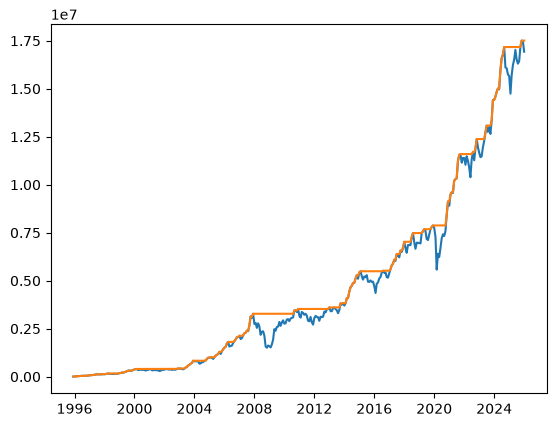

In [24]:
import matplotlib.pyplot as plt

plt.plot(dd_fixed["date"], dd_fixed["nominal_corpus"])
plt.plot(dd_fixed["date"], dd_fixed["running_peak"])
plt.show()

In [49]:
dd_fixed = dd_fixed.with_columns(
        ((pl.col('nominal_corpus') - pl.col('running_peak')) / pl.col('running_peak')).alias('dd_pct')
        )

In [32]:
dd_fixed.head()

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1995-12-01,908.53,5000.00,5.50,5.50,5000.00,5000.00,0.00,1.00,-1.00,5000.00,0.00,100.00,5000.00,-1.00
1996-01-01,848.42,5000.00,5.89,11.40,10000.00,9536.38,-330.81,1.10,-1.00,8772.63,-763.75,91.99,9669.19,-1.00
1996-02-01,992.51,5000.00,5.04,16.43,15000.00,14072.76,1311.34,1.10,-1.00,14798.89,726.13,105.16,16311.34,-1.00
1996-03-01,985.30,5000.00,5.07,21.51,20000.00,18609.15,1192.85,1.10,-1.00,19227.77,618.63,103.32,21192.85,-1.00
1996-04-01,1114.36,5000.00,4.49,26.00,25000.00,23145.53,3968.81,1.10,-1.00,26282.71,3137.18,113.55,28968.81,-1.00


In [50]:
dd_half = dd_half.with_columns(
        ((pl.col('nominal_corpus') - pl.col('running_peak')) / pl.col('running_peak')).alias('dd_pct')
        )

In [51]:
dd_full = dd_full.with_columns(
        ((pl.col('nominal_corpus') - pl.col('running_peak')) / pl.col('running_peak')).alias('dd_pct')
        )

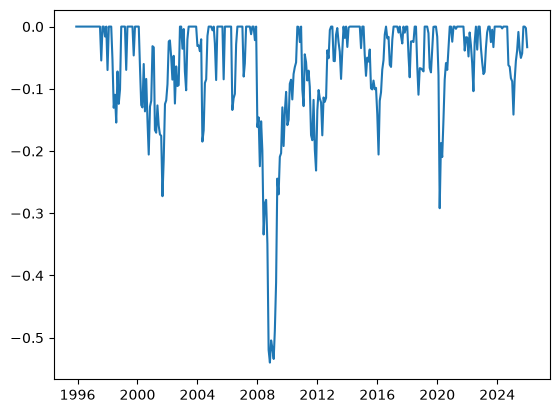

In [52]:
plt.plot(dd_fixed['date'], dd_fixed['dd_pct'])
plt.show()

In [53]:
dd_fixed.filter(
    pl.col("date").dt.year() == 2020
).select(
    "date",
    "nominal_corpus",
    "running_peak",
    "dd_pct"
)

date,nominal_corpus,running_peak,dd_pct
date,f64,f64,f64
2020-01-01,7750551.67,7879164.88,-0.02
2020-02-01,7262901.39,7879164.88,-0.08
2020-03-01,5579540.62,7879164.88,-0.29
2020-04-01,6403617.38,7879164.88,-0.19
2020-05-01,6227028.17,7879164.88,-0.21
2020-06-01,6701185.60,7879164.88,-0.15
2020-07-01,7207924.04,7879164.88,-0.09
2020-08-01,7417345.29,7879164.88,-0.06
2020-09-01,7331187.67,7879164.88,-0.07


In [42]:
dd_fixed.schema

Schema([('date', Date),
        ('price', Float64),
        ('monthly_contribution', Float64),
        ('units_bought', Float64),
        ('total_units', Float64),
        ('total_contributions', Float64),
        ('real_contributions', Float64),
        ('investment_gain', Float64),
        ('inflation_factor', Float64),
        ('nominal_corpus', Float64),
        ('real_corpus', Float64),
        ('real_wealth_created', Float64),
        ('purchasing_power_retained', Float64),
        ('running_peak', Float64),
        ('dd_pct', Float64)])

In [54]:
dd_fixed.select(
    "nominal_corpus"
).head()

nominal_corpus
f64
5000.00
9669.19
16311.34
21192.85
28968.81


In [55]:
dd_fixed.select(pl.min('dd_pct'))

dd_pct
f64
-0.54


In [56]:
dd_fixed.filter(
    pl.col("dd_pct") == pl.col("dd_pct").min()
)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2008-11-01,2755.10,5000.00,1.81,547.27,780000.00,497613.78,727790.35,2.17,1507790.35,694628.09,197014.31,139.59,3277585.73,-0.54


In [57]:
dd_fixed.filter(pl.col('nominal_corpus') == 3277585.73)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2007-12-01,6138.60,5000.00,0.81,533.93,725000.00,472275.68,2552585.73,2.04,3277585.73,1606144.45,1133868.78,340.09,3277585.73,0.00


In [58]:
dd_fixed.head()

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1995-12-01,908.53,5000.00,5.50,5.50,5000.00,5000.00,0.00,1.00,5000.00,5000.00,0.00,100.00,5000.00,0.00
1996-01-01,848.42,5000.00,5.89,11.40,10000.00,9536.38,-330.81,1.10,9669.19,8772.63,-763.75,91.99,9669.19,0.00
1996-02-01,992.51,5000.00,5.04,16.43,15000.00,14072.76,1311.34,1.10,16311.34,14798.89,726.13,105.16,16311.34,0.00
1996-03-01,985.30,5000.00,5.07,21.51,20000.00,18609.15,1192.85,1.10,21192.85,19227.77,618.63,103.32,21192.85,0.00
1996-04-01,1114.36,5000.00,4.49,26.00,25000.00,23145.53,3968.81,1.10,28968.81,26282.71,3137.18,113.55,28968.81,0.00


In [59]:
dd_half.head()

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1995-12-01,908.53,5000.00,5.50,5.50,5000.00,5000.00,0.00,1.00,5000.00,5000.00,0.00,100.00,5000.00,0.00
1996-01-01,848.42,5255.50,6.19,11.70,10255.50,9768.19,-330.81,1.10,9924.69,9004.44,-763.75,92.18,9924.69,0.00
1996-02-01,992.51,5255.50,5.30,16.99,15511.00,14536.38,1354.73,1.10,16865.73,15301.88,765.50,105.27,16865.73,0.00
1996-03-01,985.30,5255.50,5.33,22.33,20766.50,19304.57,1232.21,1.10,21998.71,19958.91,654.34,103.39,21998.71,0.00
1996-04-01,1114.36,5255.50,4.72,27.04,26022.00,24072.76,4113.73,1.10,30135.73,27341.43,3268.67,113.58,30135.73,0.00


In [61]:
dd_fixed.filter(
        pl.col('nominal_corpus') > 3277585.73
        ).head(1)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2010-09-01,6029.95,5000.00,0.83,572.59,890000.00,542684.67,2562717.43,2.61,3452717.43,1324007.02,781322.35,243.97,3452717.43,0.00


In [62]:
dd_fixed.filter(pl.col('date').dt.year() < 2005).select(pl.min('dd_pct'))

dd_pct
f64
-0.27


In [71]:
dd_fixed.filter(pl.col('dd_pct').round(2) == -0.27).head(1)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2001-09-01,913.85,5000.00,5.47,320.12,350000.00,264858.91,-57456.75,1.59,292543.25,184370.46,-80488.45,69.61,402163.37,-0.27


In [72]:
dd_fixed.filter(pl.col('nominal_corpus') > 402163.37).head(1)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2002-11-01,1050.15,5000.00,4.76,387.69,420000.00,307712.70,-12863.15,1.65,407136.85,247245.28,-60467.42,80.35,407136.85,0.00


In [74]:
dd_fixed.filter(pl.col('date').dt.year() > 2019).select(pl.min('dd_pct'))

dd_pct
f64
-0.29


In [75]:
dd_fixed.filter(pl.col('dd_pct').round(2) == -0.29)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-03-01,8597.75,5000.00,0.58,648.95,1460000.00,690285.34,4119540.62,5.27,5579540.62,1058893.62,368608.28,153.40,7879164.88,-0.29


In [76]:
dd_fixed.filter(pl.col('nominal_corpus') > 7879164.88).head(1)

date,price,monthly_contribution,units_bought,total_units,total_contributions,real_contributions,investment_gain,inflation_factor,nominal_corpus,real_corpus,real_wealth_created,purchasing_power_retained,running_peak,dd_pct
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-11-01,12968.95,5000.00,0.39,652.62,1500000.00,697876.60,6963771.18,5.27,8463771.18,1606267.24,908390.64,230.16,8463771.18,0.00


In [77]:
dd_fixed.write_database(
    table_name="analysis.nifty_historical_fixed_dd",
    connection=engine,
    if_table_exists="replace"
)

-1

In [78]:
dd_half.write_database(
    table_name="analysis.nifty_historical_half_dd",
    connection=engine,
    if_table_exists="replace"
)

-1

In [79]:
dd_full.write_database(
    table_name="analysis.nifty_historical_full_dd",
    connection=engine,
    if_table_exists="replace"
)

-1